In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
# 1 imports and paths
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config

main_folder = "../.."
img_folder  = os.path.join(main_folder, "data", "train")
out_dir     = os.path.join(main_folder, "outputs", "extra", "exp16_swin_384_strong_MSELoss_saliency_strongHead")
out_csv     = os.path.join(main_folder, "data", "train_brisque_visibility_ratio.csv")

os.makedirs(out_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
#  generate pseudo-labels if not already done, load CSV, set cfg

import sys
sys.path.insert(0, os.path.join(main_folder))
from src.gen_pseudo_labels import generate_pseudo_labels

# --- generate all pseudo-labels (skips if CSV already exists) ---
df_raw = pd.read_csv(os.path.join(main_folder, "data", "train.csv"))

df = generate_pseudo_labels(
    df=df_raw,
    img_folder=img_folder,
    out_csv=out_csv,
    run_brisque=False,
    run_yolo=True,
    force_recompute=False,
)


TARGET = "Pawpularity"

# --- set cfg ---
cfg = EXP_CONFIGS["exp15_aux_brisque"].copy()
cfg["img_size"] = 384
cfg["name"]     = "exp16_swin_384_strong_MSELoss_saliency_strongHead"
cfg["loss"]     = "mse"
cfg["head_type"] = "mlp"#strong head , linear or mlp
cfg["use_saliency"] = True
cfg["aux_tasks"] = []
cfg["aux_loss_weights"] = {"saliency": 0.1}

save_config(cfg, out_dir)
set_seed(cfg["seed"])



Pseudo-label CSV already exists, loading: ../../data/train_brisque_visibility_ratio.csv


In [8]:

from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)


    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp16_swin_384_strong_MSELoss_saliency_strongHead: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: PawRMSE=23.7982 TotalLoss=566.4522 | ValRMSE: 21.0950 | train_loss_saliency: 0.9937
Epoch 2/10 | Fold 1 | Train[MSE]: PawRMSE=20.5297 TotalLoss=421.5690 | ValRMSE: 21.0247 | train_loss_saliency: 1.0022
Epoch 3/10 | Fold 1 | Train[MSE]: PawRMSE=20.5167 TotalLoss=421.0364 | ValRMSE: 21.0395 | train_loss_saliency: 0.9987
Epoch 4/10 | Fold 1 | Train[MSE]: PawRMSE=20.3979 TotalLoss=416.1722 | ValRMSE: 20.0815 | train_loss_saliency: 0.9923
Epoch 5/10 | Fold 1 | Train[MSE]: PawRMSE=18.9838 TotalLoss=360.4850 | ValRMSE: 18.5139 | train_loss_saliency: 1.0160
Epoch 6/10 | Fold 1 | Train[MSE]: PawRMSE=17.5841 TotalLoss=309.3033 | ValRMSE: 17.9659 | train_loss_saliency: 1.0207
Epoch 7/10 | Fold 1 | Train[MSE]: PawRMSE=16.7129 TotalLoss=279.4219 | ValRMSE: 17.8848 | train_loss_saliency: 1.0236
Epoch 8/10 | Fold 1 | Train[MSE]: PawRMSE=16.1140 TotalLoss=259.7628 | ValRMSE: 17.8663 | train_loss_salien

In [9]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 17.7790 (n=1983)
Fold 2 OOF RMSE: 18.0829 (n=1983)
Fold 3 OOF RMSE: 17.3645 (n=1982)
Fold 4 OOF RMSE: 17.5475 (n=1982)
Fold 5 OOF RMSE: 17.9243 (n=1982)


In [21]:
#  per-epoch BRISQUE val MSE curve
# Aux loss

all_logs = []
for fold in range(1, 6):
    lp = os.path.join(out_dir, f"epoch_logs_fold{fold}.csv")
    if os.path.exists(lp):
        all_logs.append(pd.read_csv(lp))

if all_logs:
    logs_df = pd.concat(all_logs).reset_index(drop=True)

    if "val_brisque_mse" in logs_df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        for fold_i in range(1, 6):
            fold_log = logs_df[logs_df["fold"] == fold_i]
            if fold_log.empty:
                continue
            axes[0].plot(fold_log["epoch"], fold_log["val_rmse"],
                         label=f"fold {fold_i}", alpha=0.85)
            axes[1].plot(fold_log["epoch"], fold_log["val_brisque_mse"],
                         label=f"fold {fold_i}", alpha=0.85)

        axes[0].set_title("Main task — val RMSE (Pawpularity) per epoch")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("RMSE")
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)

        axes[1].set_title("Aux head — val MSE (BRISQUE) per epoch\n"
                          )
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MSE")
        axes[1].legend(fontsize=8)
        axes[1].grid(alpha=0.3)

        plt.suptitle("Aux-task learning curves", fontsize=11)
        plt.tight_layout()
        
        plt.show()

       

In [12]:
logs_df.head()

,fold,epoch,train_loss,train_paw_loss,val_rmse,loss_saliency
0,1,1,566.452199,566.352827,21.094954,0.993710
1,1,2,421.568983,421.468765,21.024691,1.002191
2,1,3,421.036441,420.936570,21.039469,0.998708
3,1,4,416.172219,416.072991,20.081499,0.992279
4,1,5,360.485002,360.383403,18.513884,1.015987


### Training and Validation Loss Curve

In [ ]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs","extra", "exp3_swin_384_strong_MSE_")


### Side by Side Comparison with Image only

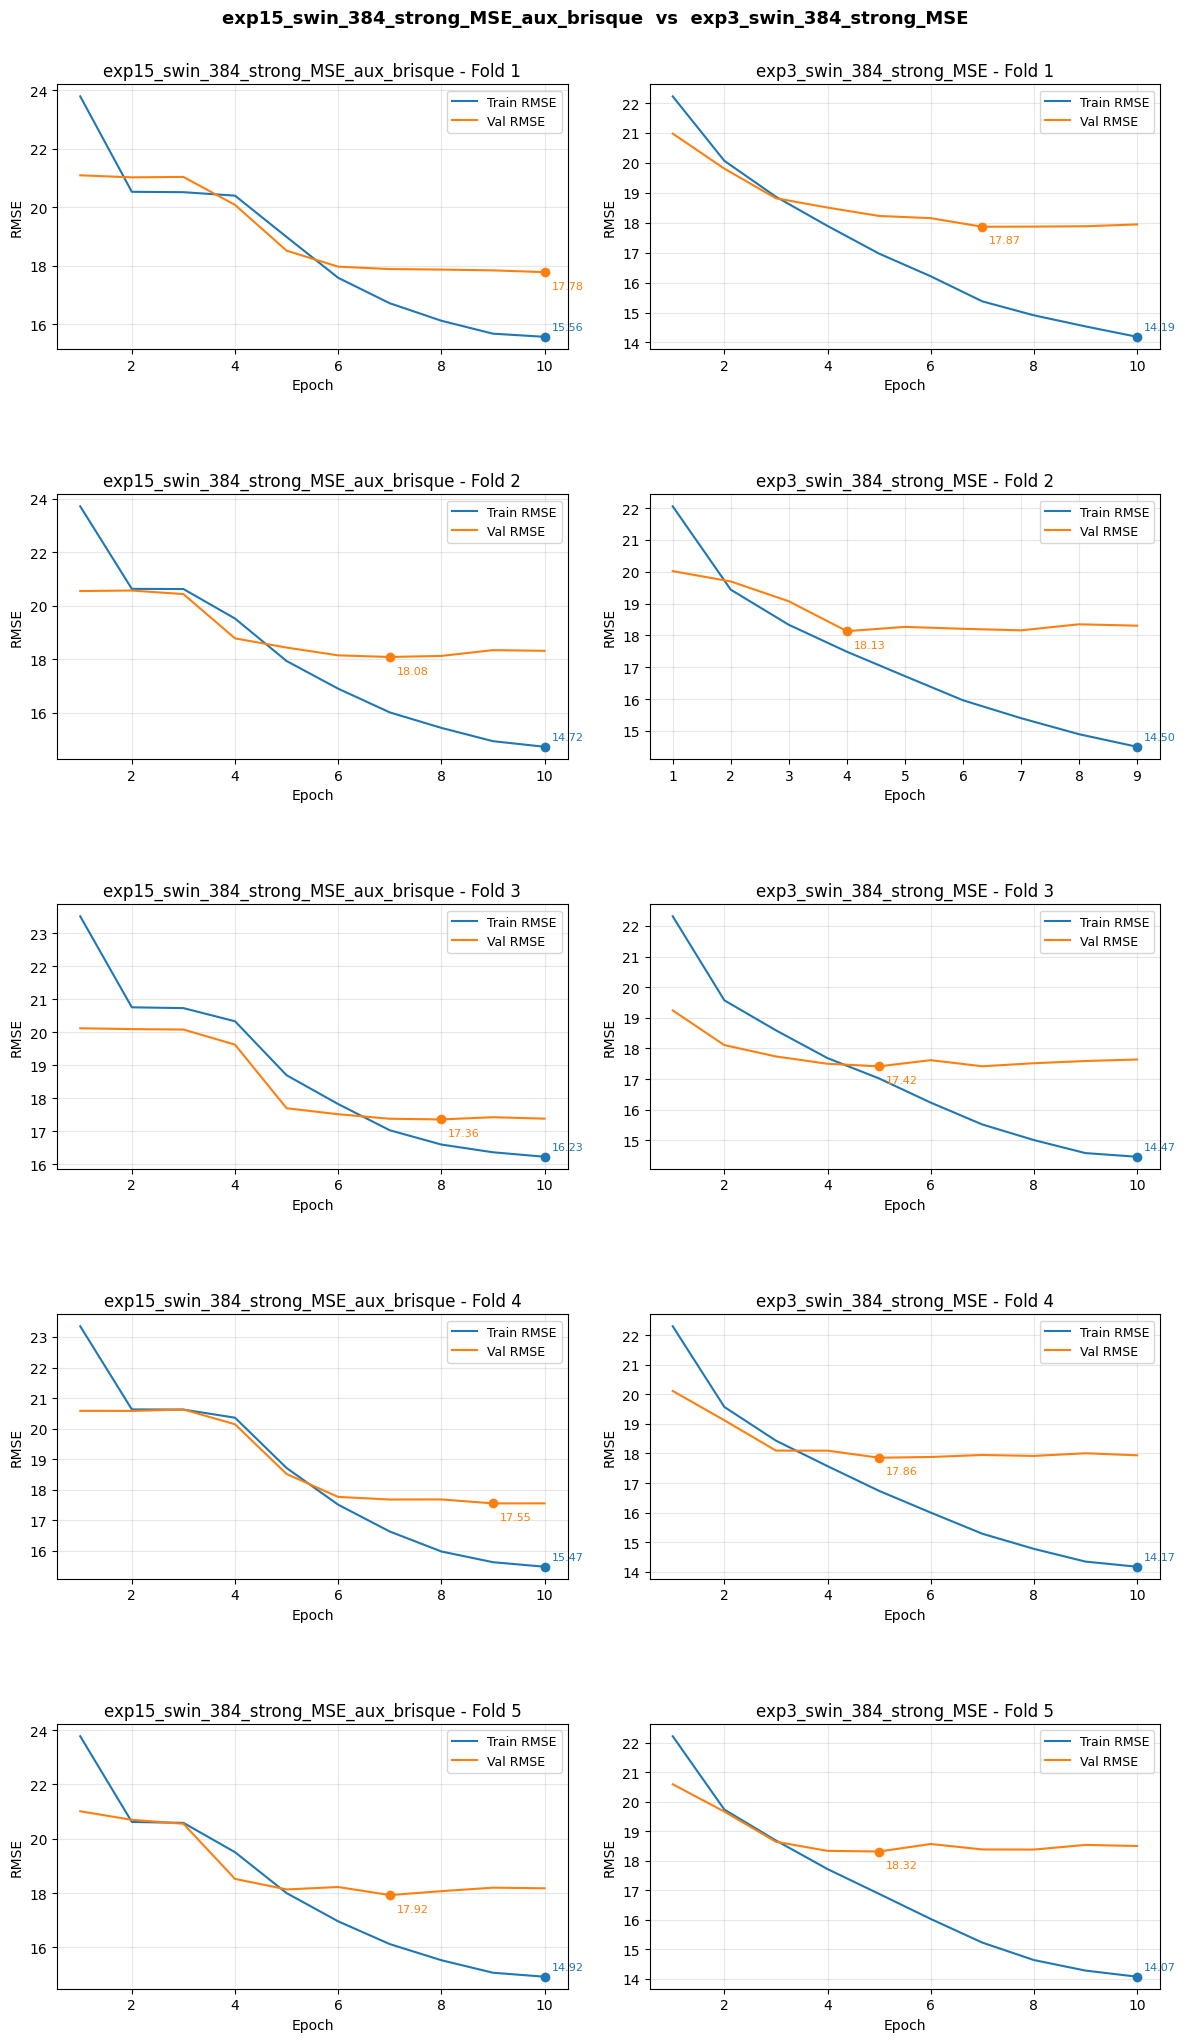

In [14]:
### Side by Side Comparison with Concatenation based Feature Fusion Exp4
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="exp15_swin_384_strong_MSE_aux_brisque", label_b="exp3_swin_384_strong_MSE")


In [15]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,4435d6f98ad72782ca0cf61f946b016d,5,100,26.121943,73.878057
1,e638853bdec13e6cc76b69f169b34740,4,96,25.151373,70.848627
2,12b136b947a64c8b23e3929f70b41933,1,100,30.195887,69.804113
3,4c1e05895368c997fdd709bbd1ac3dae,2,2,71.644485,69.644485
4,48a66727373de4e7fa7bb3331cd9acc8,3,96,26.443893,69.556107


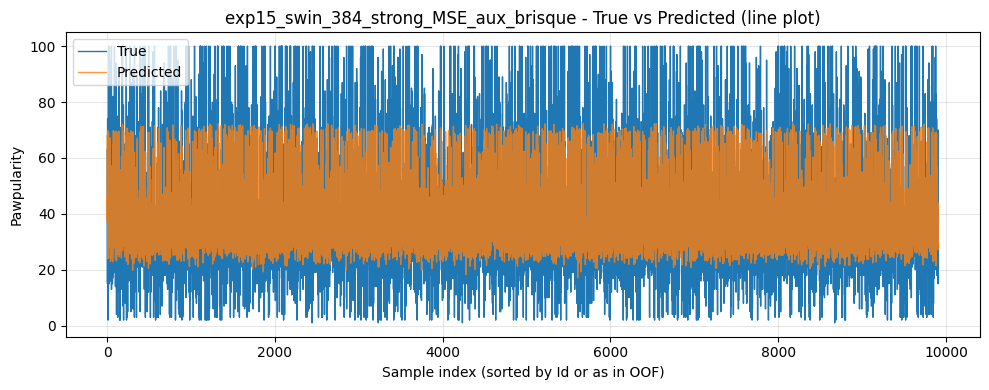

In [16]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="exp15_swin_384_strong_MSE_aux_brisque")





exp15_swin_384_strong_MSE_aux_brisque OOF RMSE: 17.741561114505984
exp3_swin_384_strong_MSE OOF RMSE: 17.920736475104714
ΔRMSE (exp3_swin_384_strong_MSE - exp15_swin_384_strong_MSE_aux_brisque): 0.1791753605987303


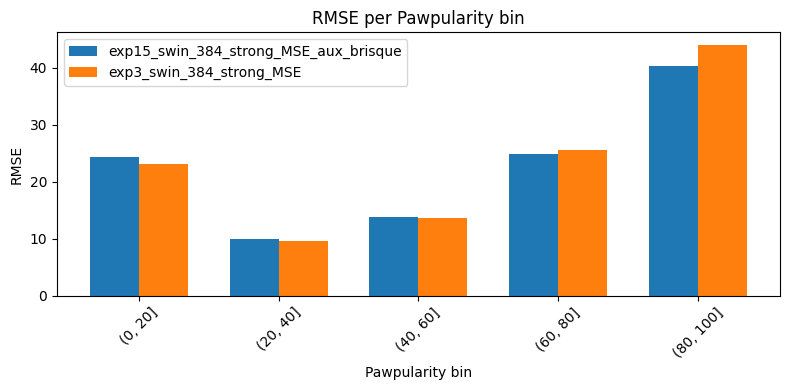

In [17]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="exp15_swin_384_strong_MSE_aux_brisque",
    label_b="exp3_swin_384_strong_MSE",
    title_prefix="",
)

In [18]:
df_bins.head()

,bin,count,exp15_swin_384_strong_MSE_aux_brisque_rmse,exp3_swin_384_strong_MSE_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.368118,23.184814,-1.183304,exp3_swin_384_strong_MSE_better
1,"(20, 40]",5119,9.979797,9.621530,-0.358267,exp3_swin_384_strong_MSE_better
2,"(40, 60]",2088,13.915437,13.566323,-0.349113,exp3_swin_384_strong_MSE_better
3,"(60, 80]",727,24.934367,25.544517,0.610150,exp15_swin_384_strong_MSE_aux_brisque_better
4,"(80, 100]",561,40.327618,44.059252,3.731634,exp15_swin_384_strong_MSE_aux_brisque_better


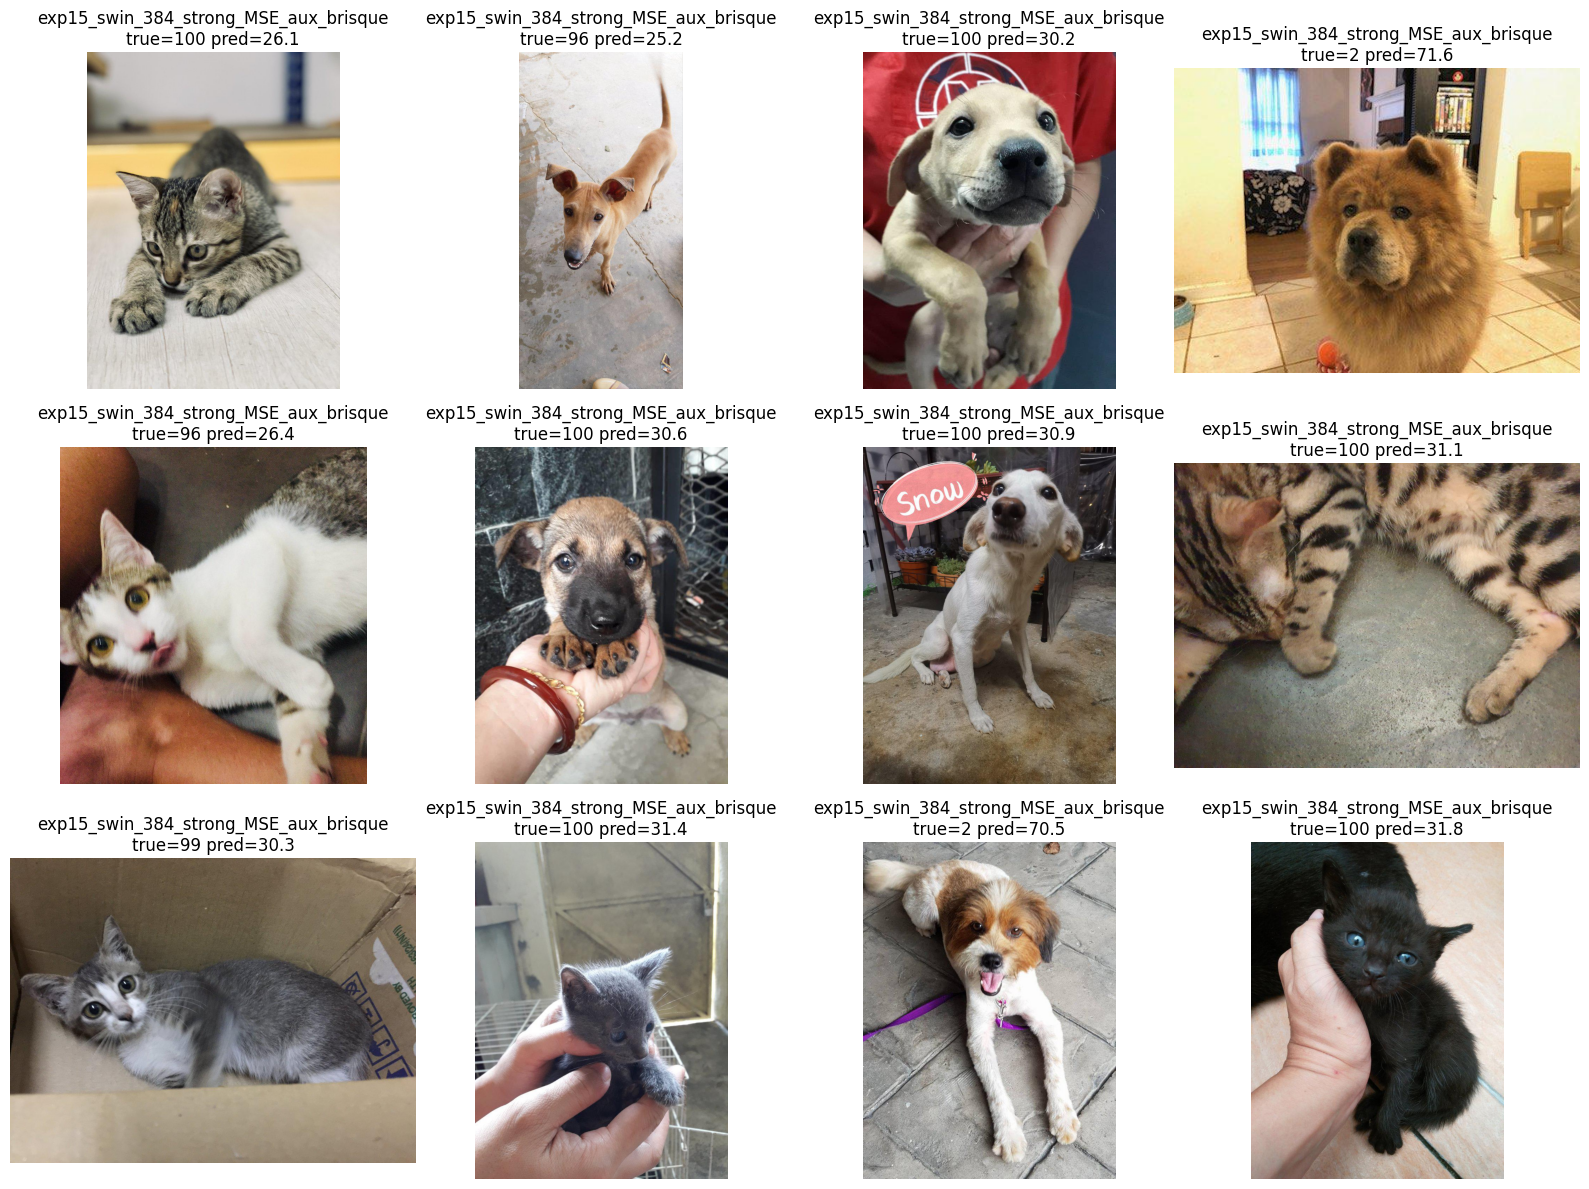

In [19]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp15_swin_384_strong_MSE_aux_brisque")

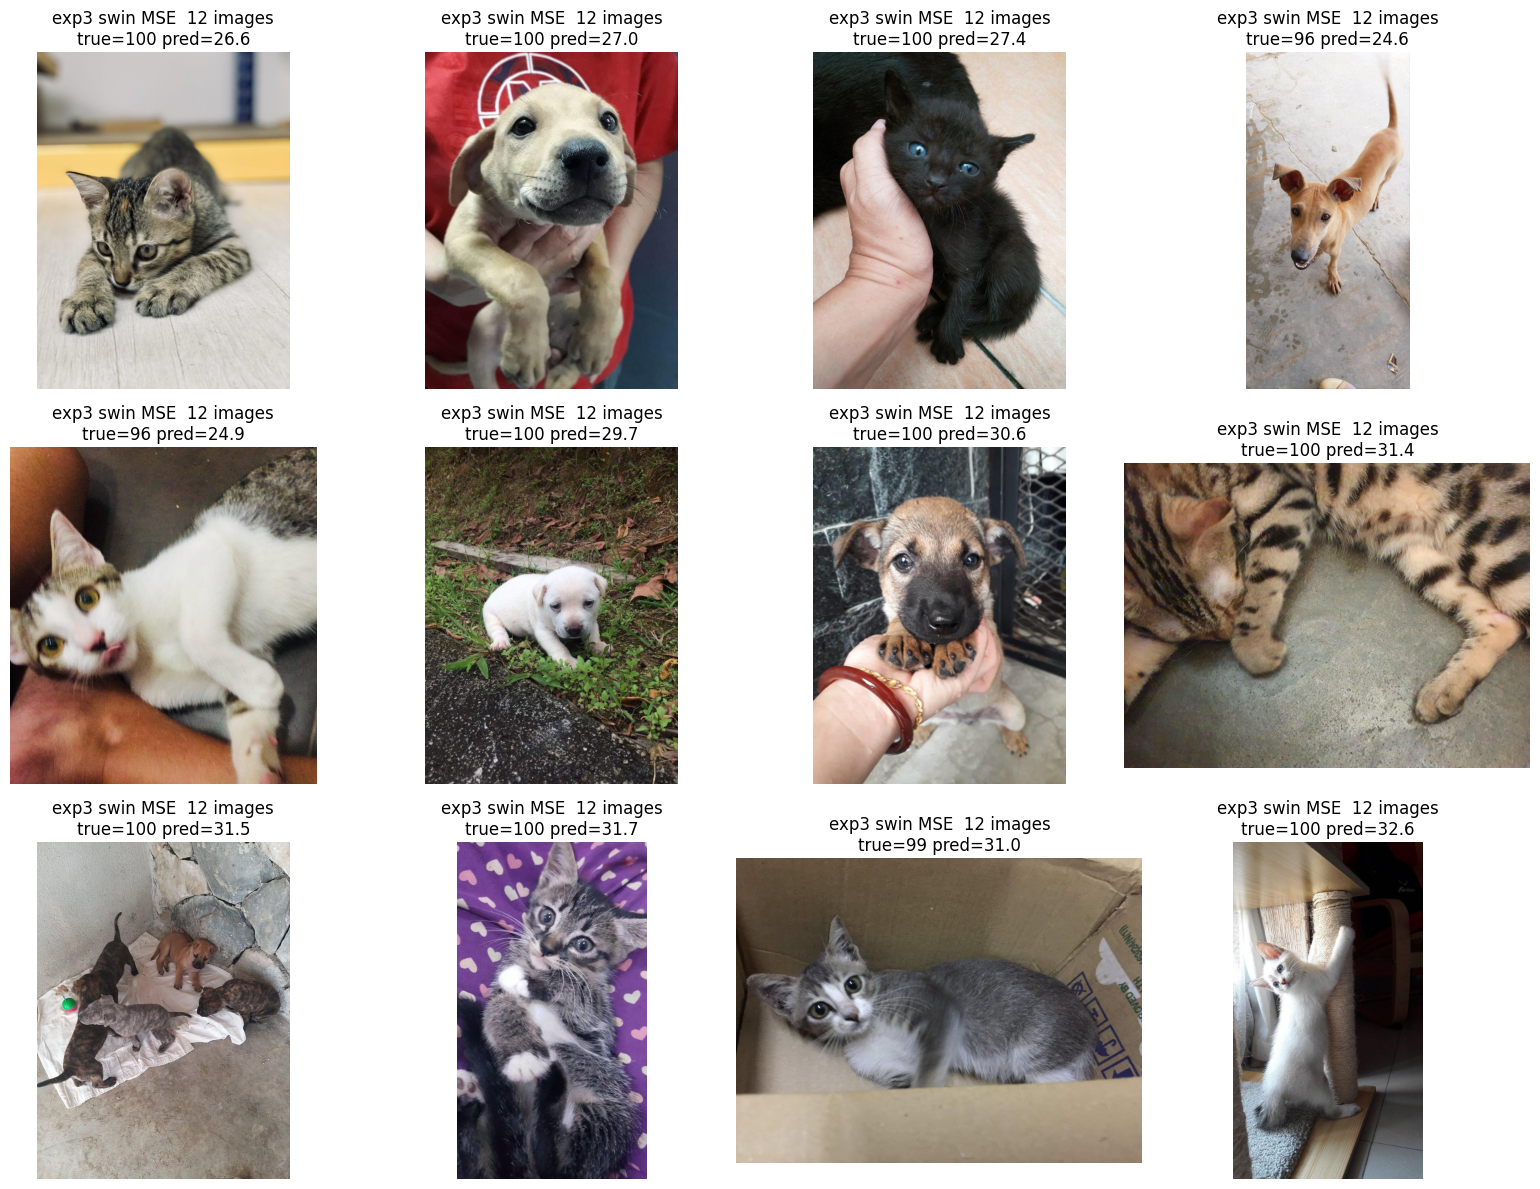

In [20]:
# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp3 swin MSE  12 images")